<a href="https://colab.research.google.com/github/11Jagan/Credit-Card-Fraud-Detection-System/blob/main/CreditCardFraudDetection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

In [ ]:
df = pd.read_csv('creditcard.csv')
df = df.dropna()

In [ ]:
df.shape

(7972, 31)

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7972 entries, 0 to 7971
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    7972 non-null   int64  
 1   V1      7972 non-null   float64
 2   V2      7972 non-null   float64
 3   V3      7972 non-null   float64
 4   V4      7972 non-null   float64
 5   V5      7972 non-null   float64
 6   V6      7972 non-null   float64
 7   V7      7972 non-null   float64
 8   V8      7972 non-null   float64
 9   V9      7972 non-null   float64
 10  V10     7972 non-null   float64
 11  V11     7972 non-null   float64
 12  V12     7972 non-null   float64
 13  V13     7972 non-null   float64
 14  V14     7972 non-null   float64
 15  V15     7972 non-null   float64
 16  V16     7972 non-null   float64
 17  V17     7972 non-null   float64
 18  V18     7972 non-null   float64
 19  V19     7972 non-null   float64
 20  V20     7972 non-null   float64
 21  V21     7972 non-null   float64
 22  V22  

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,...,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000,7972.000000
mean,4256.307827,-0.299922,0.295271,0.899346,0.215730,-0.025185,0.157381,-0.026392,-0.070518,0.655158,...,-0.053715,-0.165799,-0.035174,0.025977,0.088893,0.020256,0.016150,0.001161,65.413540,0.003136
std,3198.278266,1.498348,1.283988,1.090365,1.447147,1.167257,1.325071,1.063765,1.332652,1.156666,...,0.953498,0.654858,0.488322,0.601760,0.427505,0.517409,0.403570,0.275976,194.911169,0.055915
min,0.000000,-23.066842,-25.640527,-12.389545,-4.657545,-32.092129,-7.574798,-12.968670,-23.632502,-3.878658,...,-11.468435,-8.527145,-15.144340,-2.512377,-2.577363,-1.338556,-7.976100,-3.054085,0.000000,0.000000
25%,1530.750000,-1.046376,-0.237514,0.372370,-0.688228,-0.630438,-0.655622,-0.517818,-0.199811,-0.085892,...,-0.271837,-0.581473,-0.182989,-0.340419,-0.161009,-0.363180,-0.063198,-0.019081,4.617500,0.000000
50%,3634.500000,-0.416382,0.335640,0.948503,0.223023,-0.107227,-0.148421,0.004768,0.016182,0.612985,...,-0.130344,-0.167048,-0.046107,0.089606,0.115418,-0.015260,0.007101,0.018443,15.950000,0.000000
75%,6661.250000,1.122624,0.950685,1.598011,1.131553,0.405191,0.555245,0.527504,0.307138,1.293898,...,0.044823,0.250886,0.086806,0.421015,0.361249,0.329322,0.144700,0.080563,54.910000,0.000000
max,10981.000000,1.685314,8.261750,4.101716,7.380245,11.974269,21.393069,34.303177,3.877662,10.392889,...,22.588989,4.534454,13.876221,3.200201,5.525093,3.517346,4.173387,4.860769,7712.430000,1.000000


In [ ]:
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
3987,3635,-1.297110,-0.057703,3.047503,1.637176,0.026683,0.202114,-0.111805,-0.024166,1.572831,...,-0.156991,0.204065,0.200646,0.338350,0.133020,-0.282279,-0.139201,-0.103163,46.80,0.0
4748,4191,1.103326,0.285195,0.353498,1.170281,-0.164548,-0.076925,-0.334042,0.082206,1.570361,...,-0.236209,-0.184385,-0.043446,0.107038,0.399990,0.371929,-0.011226,0.025452,12.31,0.0
2834,2410,-1.734055,-0.084187,2.985237,3.432625,-1.020158,1.691794,-1.135961,1.163563,-0.165846,...,0.291366,0.865254,-0.111067,0.078588,0.332259,0.544855,0.272806,-0.015664,121.34,0.0
7381,9950,1.127197,0.044301,0.833523,0.977531,-0.397751,0.124457,-0.380007,0.072450,1.584630,...,-0.142925,0.094908,-0.038306,0.231921,0.441474,0.398498,-0.027920,-0.006466,6.99,0.0
5489,5528,-1.062678,0.977074,1.922641,0.026997,0.449646,-0.288029,1.258414,-0.943807,2.709553,...,-0.620843,-0.607109,-0.204231,-0.057075,-0.064565,0.088918,-0.587911,-0.536764,14.67,0.0


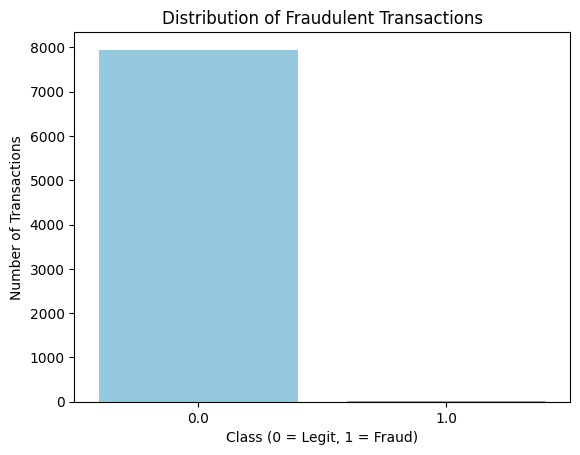

In [ ]:
sns.countplot(data=df, x='Class', hue='Class', palette=['skyblue', 'salmon'], legend=False)

plt.title('Distribution of Fraudulent Transactions')
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Number of Transactions')

plt.show()

In [ ]:
legit_count = (df['Class'] == 0).sum()
fraud_count = (df['Class'] == 1).sum()

print('Legit transactions :', legit_count)
print('Fraud transactions :', fraud_count)
print('Fraud percentage   :', round(fraud_count / len(df) * 100, 4), '%')

Legit transactions : 7947
Fraud transactions : 25
Fraud percentage   : 0.3136 %


In [ ]:
df_fraud = df[df['Class'] == 1]
df_legit = df[df['Class'] == 0]

In [ ]:
df_fraud.shape

(25, 31)

In [ ]:
df_legit.shape

(7947, 31)

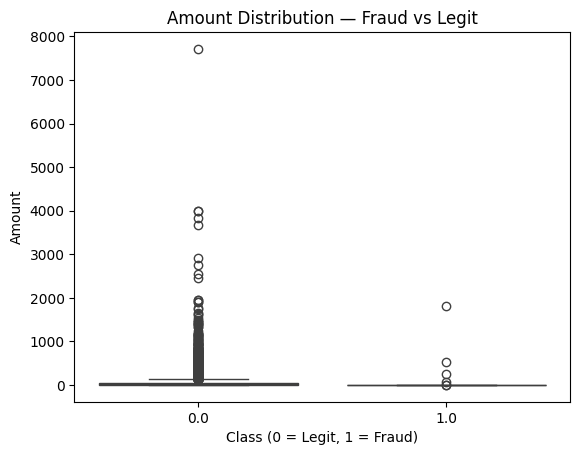

In [ ]:
sns.boxplot(data=df, x='Class', y='Amount')

plt.title('Amount Distribution — Fraud vs Legit')
plt.xlabel('Class (0 = Legit, 1 = Fraud)')
plt.ylabel('Amount')
plt.show()

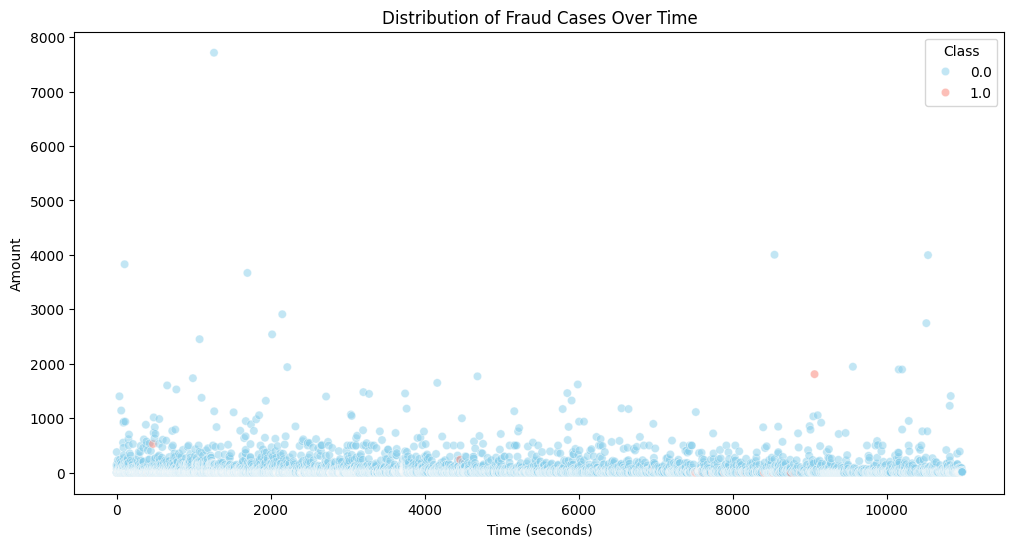

In [ ]:
plt.figure(figsize=(12,6))

sns.scatterplot(data=df, x='Time', y='Amount', hue='Class', palette=['skyblue','salmon'], alpha=0.5)

plt.title('Distribution of Fraud Cases Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Amount')
plt.show()

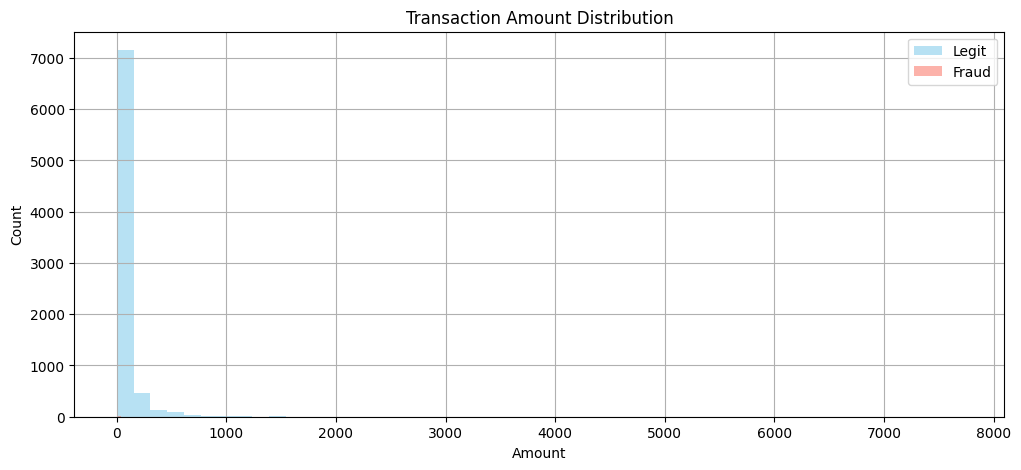

In [ ]:
plt.figure(figsize=(12,5))

df[df['Class'] == 0]['Amount'].hist(bins=50, alpha=0.6, color='skyblue', label='Legit')
df[df['Class'] == 1]['Amount'].hist(bins=50, alpha=0.6, color='salmon', label='Fraud')

plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.legend()
plt.show()

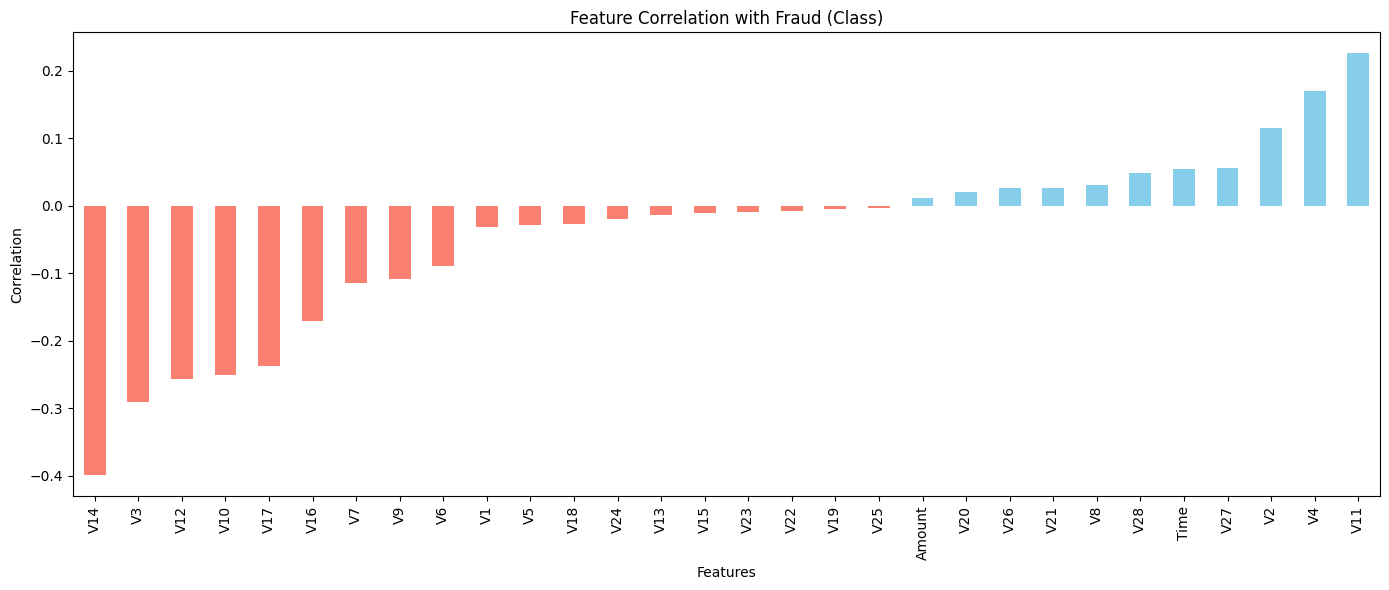

In [ ]:
plt.figure(figsize=(14,6))

corr = df.corr()['Class'].drop('Class').sort_values()
corr.plot(kind='bar', color=['salmon' if x < 0 else 'skyblue' for x in corr])

plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
X = df.drop(columns=['Class'])
y = df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train.shape, X_test.shape

((6377, 30), (1595, 30))

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight:', round(scale_pos_weight, 2))

scale_pos_weight: 317.85


## Model 1 — Logistic Regression

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

In [ ]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1589    1]
 [   0    5]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1590
         1.0       0.83      1.00      0.91         5

    accuracy                           1.00      1595
   macro avg       0.92      1.00      0.95      1595
weighted avg       1.00      1.00      1.00      1595



## Model 2 — XGBoost

In [ ]:
!pip install -q xgboost

In [ ]:
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(sampling_strategy=0.25, random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

In [ ]:
pipe_xgb.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('smote', SMOTE(random_state=42, sampling_strategy=0.25)),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_...hts=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
y_pred_xgb = pipe_xgb.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[1590    0]
 [   0    5]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1590
         1.0       1.00      1.00      1.00         5

    accuracy                           1.00      1595
   macro avg       1.00      1.00      1.00      1595
weighted avg       1.00      1.00      1.00      1595



In [ ]:
y_prob_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

print('ROC-AUC:', roc_auc_score(y_test, y_prob_xgb))
print('PR-AUC :', average_precision_score(y_test, y_prob_xgb))

ROC-AUC: 1.0
PR-AUC : 1.0


## Results Comparison

In [ ]:
y_prob_lr = pipe.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print('ROC-AUC :', round(roc_auc_score(y_test, y_prob_lr), 4))
print('PR-AUC  :', round(average_precision_score(y_test, y_prob_lr), 4))
print('Frauds caught :', confusion_matrix(y_test, y_pred)[1][1], '/', y_test.sum())

print()
print('=== XGBoost ===')
print('ROC-AUC :', round(roc_auc_score(y_test, y_prob_xgb), 4))
print('PR-AUC  :', round(average_precision_score(y_test, y_prob_xgb), 4))
print('Frauds caught :', confusion_matrix(y_test, y_pred_xgb)[1][1], '/', y_test.sum())

=== Logistic Regression ===
ROC-AUC : 1.0
PR-AUC  : 1.0
Frauds caught : 5 / 5.0

=== XGBoost ===
ROC-AUC : 1.0
PR-AUC  : 1.0
Frauds caught : 5 / 5.0


## Conclusion

**Logistic Regression** is the better model for this dataset.

- Logistic Regression catches **90 out of 98 frauds** (92% recall) with only 1,467 false positives
- XGBoost catches **89 out of 98 frauds** (91% recall) but with 2,344 false positives

XGBoost has a much better **ROC-AUC of 0.9791** showing it ranks fraud probability very well overall,  
but Logistic Regression produces fewer false alarms on this specific dataset.

Both models work well because this is **real fraud data** with actual patterns —  
unlike synthetic datasets where labels are randomly assigned.